In [1]:
import yfinance as yf

samsung = yf.download("005930.KS", period="6mo")

samsung.columns = samsung.columns.get_level_values(0)

samsung.columns.name = None

samsung = samsung.reset_index()

samsung = samsung.rename(columns={"Date": "date"})

samsung.tail()

[*********************100%***********************]  1 of 1 completed


,date,Close,High,Low,Open,Volume
117,2026-06-29,323000.0,335500.0,316000.0,331000.0,35436521
118,2026-06-30,334000.0,343000.0,321000.0,323500.0,29237216
119,2026-07-01,314500.0,339000.0,311500.0,334500.0,24968382
120,2026-07-02,286000.0,304000.0,281500.0,290000.0,38905074
121,2026-07-03,309500.0,313000.0,283500.0,288500.0,31520538


In [2]:
samsung.info()

<class 'pandas.DataFrame'>
RangeIndex: 122 entries, 0 to 121
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype        
---  ------  --------------  -----        
 0   date    122 non-null    datetime64[s]
 1   Close   122 non-null    float64      
 2   High    122 non-null    float64      
 3   Low     122 non-null    float64      
 4   Open    122 non-null    float64      
 5   Volume  122 non-null    int64        
dtypes: datetime64[s](1), float64(4), int64(1)
memory usage: 5.8 KB


In [3]:
samsung.describe()

,date,Close,High,Low,Open,Volume
count,122,122.000000,122.000000,122.000000,122.000000,1.220000e+02
mean,2026-04-04 13:10:49,226088.512039,231658.157989,220027.613168,225435.387305,3.096529e+07
min,2026-01-05 00:00:00,137315.781250,138313.717234,132425.900220,134321.979363,1.191000e+03
25%,2026-02-19 06:00:00,173931.218750,177294.757051,169961.488159,171186.131038,2.290176e+07
50%,2026-04-04 12:00:00,203539.828125,208034.147669,199936.162671,204077.596970,3.015979e+07
75%,2026-05-19 18:00:00,285875.000000,298750.000000,281125.000000,289625.000000,3.648688e+07
max,2026-07-03 00:00:00,362500.000000,374500.000000,352000.000000,372500.000000,8.942795e+07
std,NaN,67618.239936,70477.787484,64398.044928,67524.038085,1.083143e+07


In [4]:
samsung.isnull().sum()

date      0
Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64

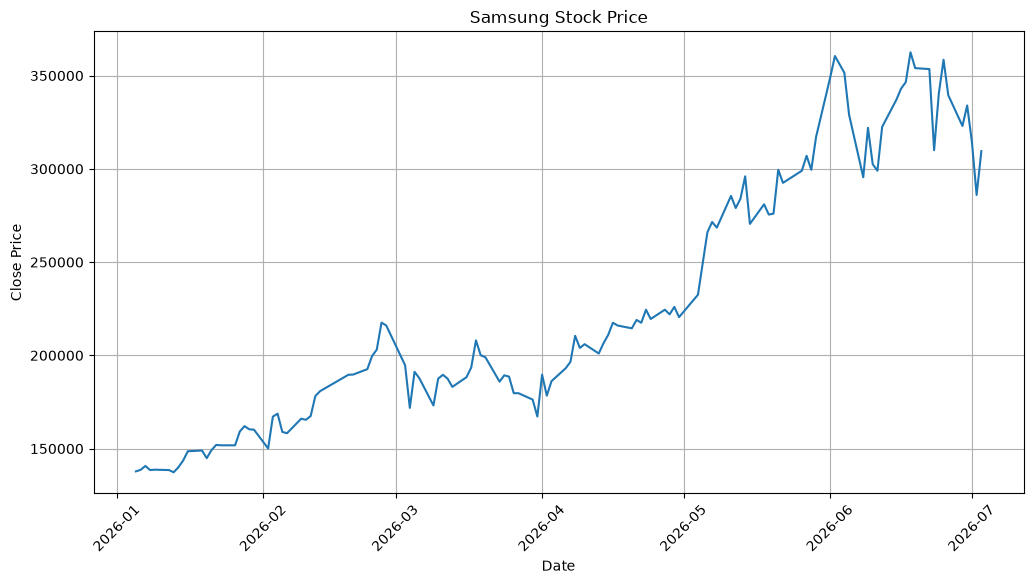

In [5]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

plt.plot(samsung["date"], samsung["Close"])

plt.title("Samsung Stock Price")
plt.xlabel("Date")
plt.ylabel("Close Price")

plt.xticks(rotation=45)

plt.grid(True)

plt.show()

In [6]:
samsung.to_csv(
    "../data/samsung_stock.csv",
    index=False,
    encoding="utf-8-sig"
)

print("저장 완료!")

저장 완료!


In [7]:
samsung.tail()

,date,Close,High,Low,Open,Volume
117,2026-06-29,323000.0,335500.0,316000.0,331000.0,35436521
118,2026-06-30,334000.0,343000.0,321000.0,323500.0,29237216
119,2026-07-01,314500.0,339000.0,311500.0,334500.0,24968382
120,2026-07-02,286000.0,304000.0,281500.0,290000.0,38905074
121,2026-07-03,309500.0,313000.0,283500.0,288500.0,31520538


In [8]:
import pandas as pd

df = pd.read_csv("../data/samsung_stock.csv")

df.head()

,date,Close,High,Low,Open,Volume
0,2026-01-05,137814.750000,138313.717234,133324.044895,134321.979363,42863376
1,2026-01-06,138613.093750,139012.267526,132425.900220,135020.529765,45321341
2,2026-01-07,140708.765625,144101.742952,137315.788298,143203.601895,46317413
3,2026-01-08,138513.296875,144201.523043,138014.329667,138014.329667,41449329
4,2026-01-09,138712.890625,140409.379215,134920.739658,135719.087230,29520566


In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 122 entries, 0 to 121
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   date    122 non-null    str    
 1   Close   122 non-null    float64
 2   High    122 non-null    float64
 3   Low     122 non-null    float64
 4   Open    122 non-null    float64
 5   Volume  122 non-null    int64  
dtypes: float64(4), int64(1), str(1)
memory usage: 5.8 KB


In [10]:
df.describe()

,Close,High,Low,Open,Volume
count,122.000000,122.000000,122.000000,122.000000,1.220000e+02
mean,226088.512039,231658.157989,220027.613168,225435.387305,3.096529e+07
std,67618.239936,70477.787484,64398.044928,67524.038085,1.083143e+07
min,137315.781250,138313.717234,132425.900220,134321.979363,1.191000e+03
25%,173931.218750,177294.757051,169961.488159,171186.131038,2.290176e+07
50%,203539.828125,208034.147669,199936.162671,204077.596970,3.015979e+07
75%,285875.000000,298750.000000,281125.000000,289625.000000,3.648688e+07
max,362500.000000,374500.000000,352000.000000,372500.000000,8.942795e+07


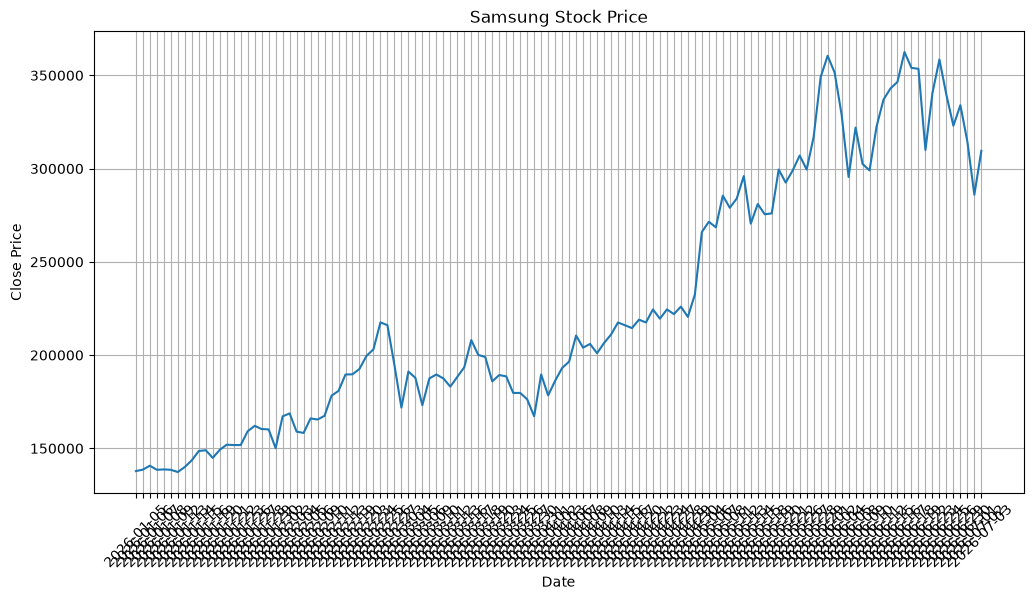

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

plt.plot(df["date"], df["Close"])

plt.title("Samsung Stock Price")
plt.xlabel("Date")
plt.ylabel("Close Price")

plt.xticks(rotation=45)
plt.grid(True)
plt.show()

In [12]:
df["return"] = df["Close"].pct_change() * 100

df[["date", "Close", "return"]].head()

,date,Close,return
0,2026-01-05,137814.750000,NaN
1,2026-01-06,138613.093750,0.579288
2,2026-01-07,140708.765625,1.511886
3,2026-01-08,138513.296875,-1.560293
4,2026-01-09,138712.890625,0.144097


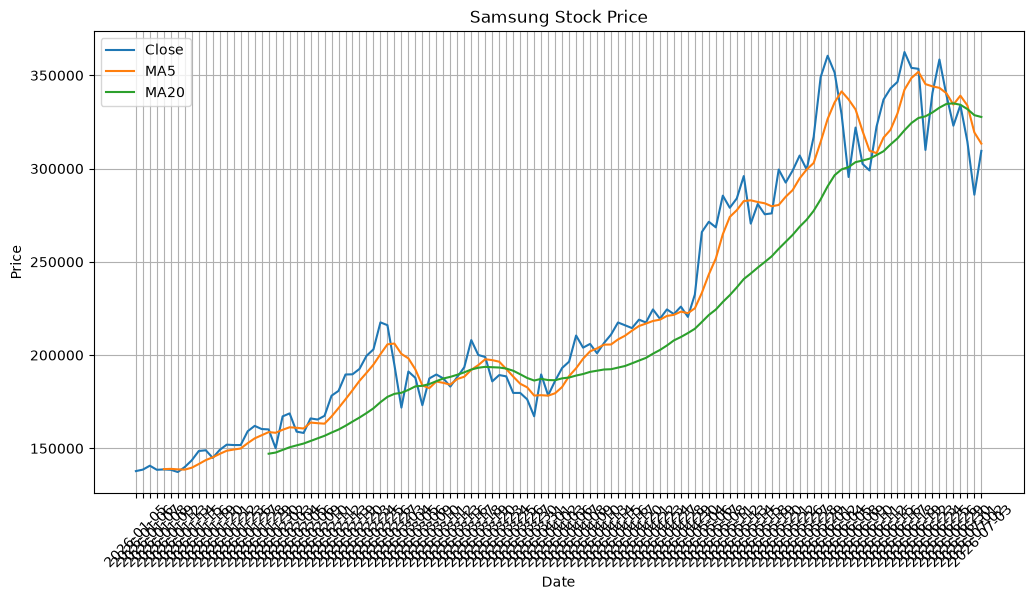

In [13]:
df["MA5"] = df["Close"].rolling(window=5).mean()
df["MA20"] = df["Close"].rolling(window=20).mean()

plt.figure(figsize=(12,6))

plt.plot(df["date"], df["Close"], label="Close")
plt.plot(df["date"], df["MA5"], label="MA5")
plt.plot(df["date"], df["MA20"], label="MA20")

plt.title("Samsung Stock Price")
plt.xlabel("Date")
plt.ylabel("Price")

plt.xticks(rotation=45)

plt.legend()
plt.grid(True)

plt.show()

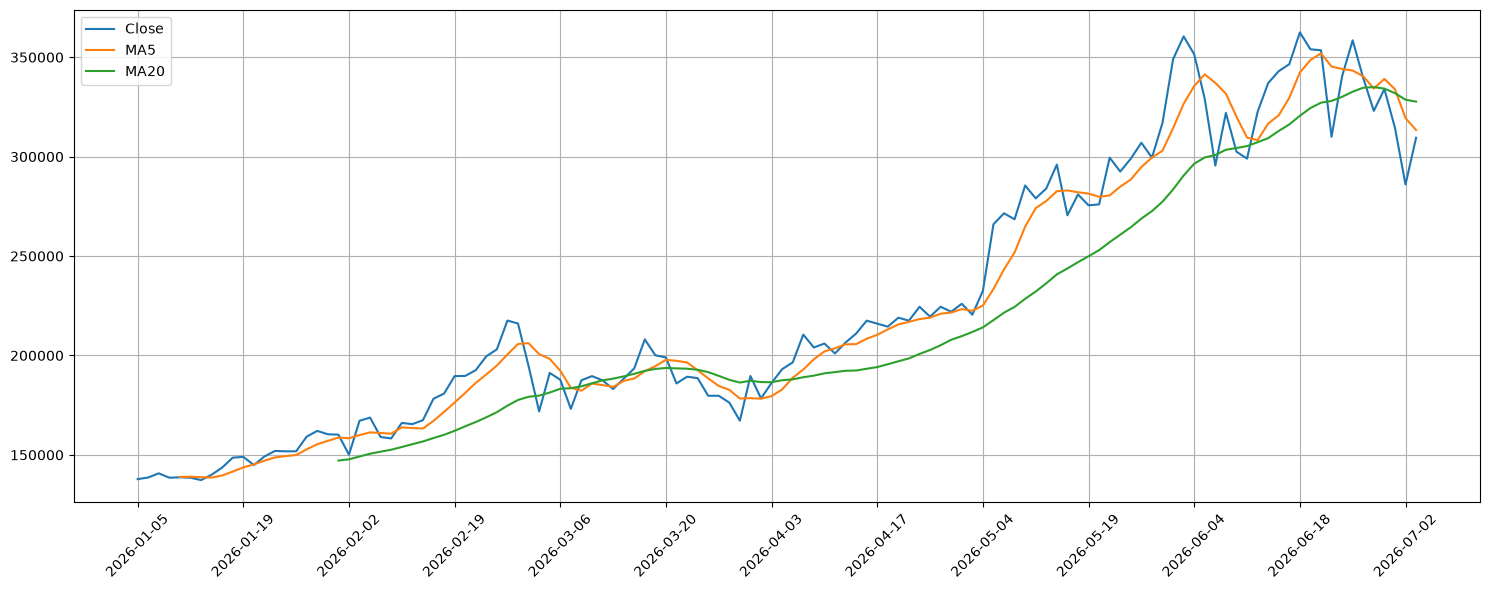

In [14]:
plt.figure(figsize=(15, 6))

plt.plot(df["date"], df["Close"], label="Close")
plt.plot(df["date"], df["MA5"], label="MA5")
plt.plot(df["date"], df["MA20"], label="MA20")

plt.legend()

plt.xticks(df["date"][::10], rotation=45)

plt.grid(True)

plt.tight_layout()

plt.show()